# Глава 1


## упражнение 1.2


### добавим wav файл и установим длительность сегмента в 0.5 секунды



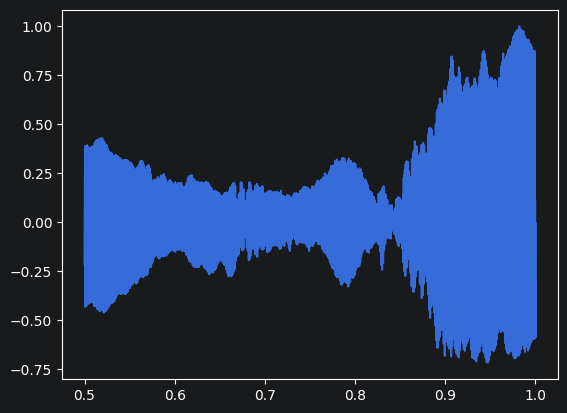

In [22]:
from thinkdsp import read_wave, decorate
wave = read_wave('92002__jcveliz__violin-origional.wav')
wave.normalize()
segment = wave.segment(start=0.5, duration=0.5)
segment.plot()

### Сделаем спектр

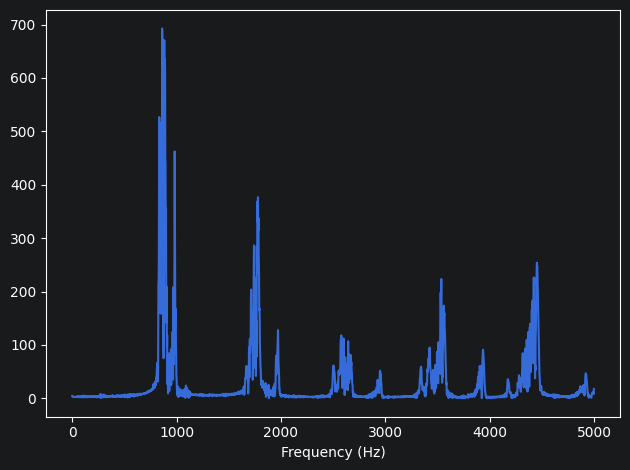

In [23]:
spectrum = segment.make_spectrum()
spectrum.plot(high=5000)
decorate(xlabel="Frequency (Hz)")


### По графику можно отследить пики
Первый заметный пик находится примерно на 900 Гц.
Второй высокий пик — около 1800 Гц.
Третий пик — около 3600 Гц.

## Отфильтруем гармоники


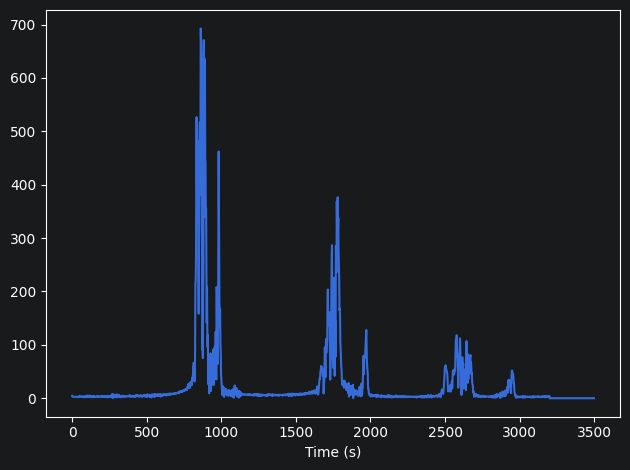

In [24]:
spectrum.low_pass(3200)
spectrum.plot(high=3500)
decorate(xlabel="Time (s)")

## Преобразуем в wav

In [25]:
filtered = spectrum.make_wave()
filtered.make_audio()

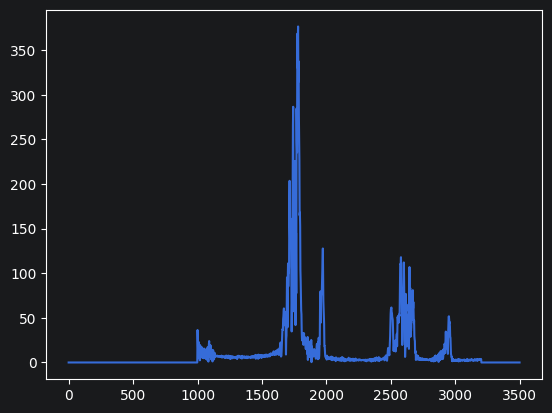

In [26]:
spectrum.high_pass(1000)
spectrum.plot(high=3500)

In [27]:
filtered = spectrum.make_wave()
filtered.make_audio()

Звук стал выше

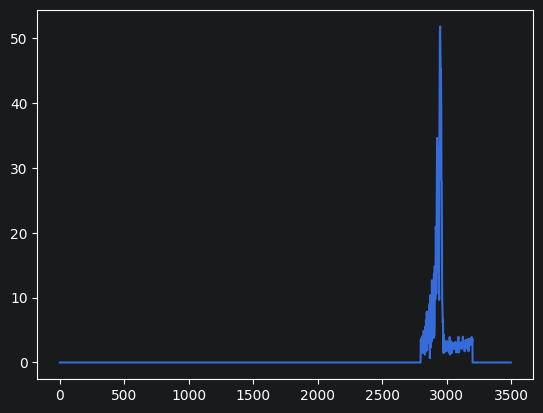

In [29]:
spectrum.band_stop(200, 2800)
spectrum.plot(high=3500)

In [30]:
filtered = spectrum.make_wave()
filtered.make_audio()

Звук совсем изменился до неузнаваемости.

## Задание 1.3


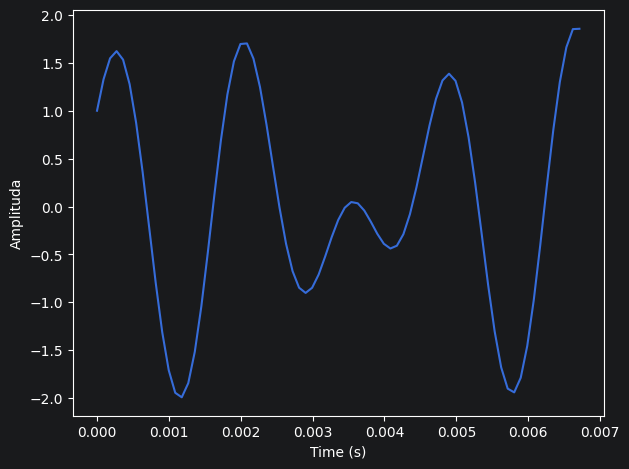

In [31]:
from thinkdsp import CosSignal, SinSignal

cos_signal = CosSignal(freq=440)
sin_signal = SinSignal(freq=644)

mix = cos_signal + sin_signal
mix.plot()
decorate(xlabel="Time (s)", ylabel="Amplituda")



### Вычислим спектр

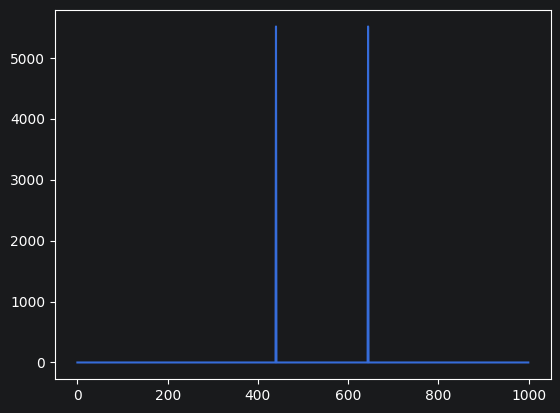

In [32]:
mix_wave = mix.make_wave()
spectrum = mix_wave.make_spectrum()
spectrum.plot(high=1000)

### Добавим компоненту некратную исходным

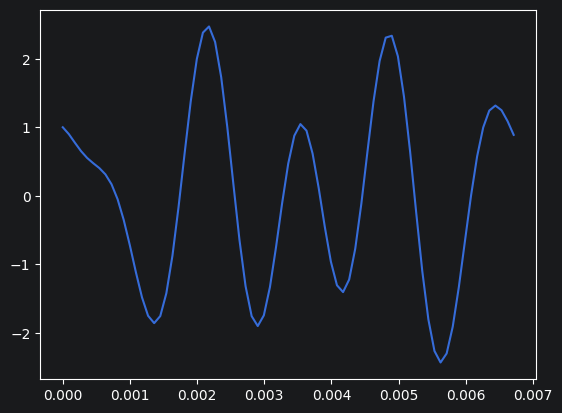

In [33]:
from thinkdsp import PI2
mix = mix + CosSignal(776, offset=PI2/4)
mix.plot()

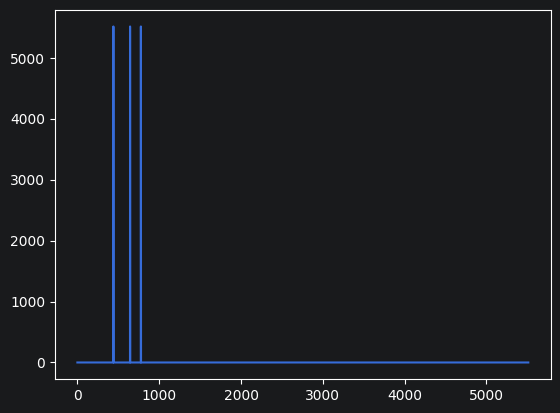

In [34]:
mix_wave = mix.make_wave()
spectrum = mix_wave.make_spectrum()
spectrum.plot()

Что и требовалось доказать - в спектре появятся новые частоты и сигнал потеряет переодичность. Попробуем добавить крутную частоту к спектру.

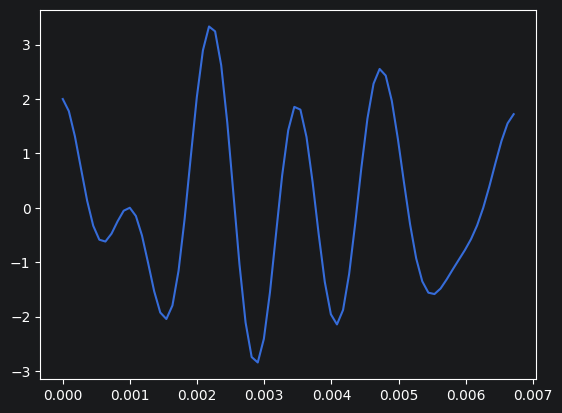

In [35]:
mix = mix + CosSignal(880)
mix.plot()

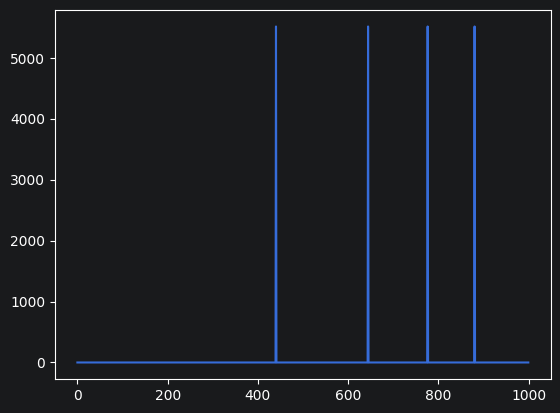

In [36]:
mix_wave = mix.make_wave()
spectrum = mix_wave.make_spectrum()
spectrum.plot(high=1000)

## Упражнение 1.4

In [37]:
from thinkdsp import Wave


def stretch(wave: Wave, multiply_by: float) -> Wave:
    wave.ts *= multiply_by
    wave.framerate /= multiply_by
    return wave

wave.make_audio()

In [38]:
stretch(wave, multiply_by=0.25).make_audio()

In [39]:
stretch(wave, multiply_by=16).make_audio()

stretch(×16) — framerate уменьшился вдвое, длина стала 20 секунды —
замедление


stretch(×0.25) — framerate увеличился вдвое, длина стала 1 секунду
— ускорение